In [1]:
!pip install sentencepiece

In [2]:
from nltk.translate.bleu_score import sentence_bleu
import nltk
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## Загрузка библиотек

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm
import warnings
import math
import sentencepiece as spm
import random
from nltk.translate.bleu_score import sentence_bleu
import nltk
nltk.download('punkt_tab')

warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## Загрузка ДАТАСЕТА

In [4]:
dataset = load_dataset("wmt19", "ru-en", split="train[:500_000]")
val_dataset = load_dataset("wmt19", "ru-en", split="validation[:50_000]")

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

In [5]:
en_texts = [item['translation']['en'] for item in dataset]
ru_texts = [item['translation']['ru'] for item in dataset]

with open("bpe_train.en", "w", encoding="utf-8") as f:
    for line in en_texts:
        f.write(line.replace('\n', ' ') + '\n')

with open("bpe_train.ru", "w", encoding="utf-8") as f:
    for line in ru_texts:
        f.write(line.replace('\n', ' ') + '\n')

In [6]:
%cp /kaggle/input/dataset-dl/* /kaggle/working/

## Загрузка токенизаторов BPE, обученного до этого датасете

In [7]:
sp_en = spm.SentencePieceProcessor()
sp_en.load('bpe_en (1).model')
sp_ru = spm.SentencePieceProcessor()
sp_ru.load('bpe_ru (1).model')

True

## Токенизация датасетов и создание DataLoader-ов

In [8]:
class BPEDataset(Dataset):
    def __init__(self, data, src_sp, trg_sp, max_len=80):
        self.data = data
        self.src_sp = src_sp
        self.trg_sp = trg_sp
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]['translation']

        src_ids = [1] + self.src_sp.encode(item['en'], out_type=int)[:self.max_len-2] + [2]
        trg_ids = [1] + self.trg_sp.encode(item['ru'], out_type=int)[:self.max_len-2] + [2]

        src_ids += [0] * (self.max_len - len(src_ids))
        trg_ids += [0] * (self.max_len - len(trg_ids))
        return torch.tensor(src_ids), torch.tensor(trg_ids)

train_dataset = BPEDataset(dataset, sp_en, sp_ru, max_len=60)
val_dataset_obj = BPEDataset(val_dataset, sp_en, sp_ru, max_len=60)

train_loader = DataLoader(train_dataset, batch_size=200, shuffle=True)
val_loader = DataLoader(val_dataset_obj, batch_size=200)

## Для добавления позиционных эмбеддингов к входу


In [9]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)

## Архитектура модели

In [ ]:
class TransformerSeq2Seq(nn.Module):

    def __init__(self, src_vocab_size, trg_vocab_size, d_model=256, nhead=4,
                 num_encoder_layers=3, num_decoder_layers=3, dim_feedforward=512,
                 dropout=0.1, max_len=80):
        super().__init__()

        self.d_model = d_model
        self.src_pad_idx = 0
        self.trg_pad_idx = 0

        self.src_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=self.src_pad_idx)
        self.trg_embedding = nn.Embedding(trg_vocab_size, d_model, padding_idx=self.trg_pad_idx)

        self.pos_encoder = PositionalEncoding(d_model, max_len, dropout)

        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            norm_first=True,
            batch_first=False
        )

        self.fc_out = nn.Linear(d_model, trg_vocab_size)

    def make_src_padding_mask(self, src):
        src = src.transpose(0, 1)
        mask = (src == self.src_pad_idx)
        return mask

    def make_trg_padding_mask(self, trg):
        trg = trg.transpose(0, 1)
        mask = (trg == self.trg_pad_idx)
        return mask

    def make_trg_mask(self, trg):
        seq_len = trg.size(0)
        trg_mask = torch.triu(torch.ones((seq_len, seq_len), device=trg.device), diagonal=1).bool()
        return trg_mask

    def forward(self, src, trg):
        src = src.transpose(0, 1)
        trg = trg.transpose(0, 1)

        src_padding_mask = self.make_src_padding_mask(src)
        trg_padding_mask = self.make_trg_padding_mask(trg)
        trg_mask = self.make_trg_mask(trg)

        src_emb = self.pos_encoder(self.src_embedding(src) * math.sqrt(self.d_model))
        trg_emb = self.pos_encoder(self.trg_embedding(trg) * math.sqrt(self.d_model))

        out = self.transformer(
            src=src_emb,
            tgt=trg_emb,
            src_mask=None,
            tgt_mask=trg_mask,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=trg_padding_mask
        )

        logits = self.fc_out(out)
        return logits.transpose(0, 1)

In [11]:
class WarmupScheduler:
    def __init__(self, optimizer, d_model, warmup_steps=4000):
        self.optimizer = optimizer
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        self.step_num = 0
        
    def step(self):
        self.step_num += 1
        lr = self.get_lr()
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
            
    def get_lr(self):
        return self.d_model ** (-0.5) * min(
            self.step_num ** (-0.5),
            self.step_num * self.warmup_steps ** (-1.5)
        )

In [12]:
print(sp_en.get_piece_size())

24000


## Создание модели

In [13]:
model = TransformerSeq2Seq(
    src_vocab_size=sp_en.get_piece_size(),
    trg_vocab_size=sp_ru.get_piece_size(),
    d_model=304,
    nhead=8,
    num_encoder_layers=4,
    num_decoder_layers=4,
    dim_feedforward=1024,
    dropout=0.1,
    max_len=60
)

def init_weights(m):
    for p in m.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)
model.apply(init_weights)
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"  - Всего параметров: {total_params:,}")


  - Всего параметров: 31,367,296


In [14]:
def decode_sequence(tokens, sp_processor):
    filtered = []
    for token in tokens:
        if token == 0: continue
        if token == 2: break
        filtered.append(token)
    return sp_processor.decode(filtered)


## Функции для валидации

In [ ]:
import random

def translate_sentence(model, src_tensor, sp_ru, max_len=60, device='cuda'):
    model.eval()
    
    if src_tensor.dim() == 1:
        src_tensor = src_tensor.unsqueeze(0)

    with torch.no_grad():
        src_tensor = src_tensor.to(device)
        trg_indices = [1]
        
        for _ in range(max_len):

            trg_tensor = torch.tensor(trg_indices, dtype=torch.long, device=device).unsqueeze(0)
            
            output = model(src_tensor, trg_tensor) 
            pred_token = output.argmax(-1)[:, -1].item()
            
            if pred_token == 2:
                break
            
            trg_indices.append(pred_token)

    return sp_ru.decode(trg_indices[1:])

def evaluate(model, loader, criterion, device, sp_ru, num_bleu_samples=100):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for src, trg in tqdm(loader, desc="Validating Loss", leave=False):
            src, trg = src.to(device), trg.to(device)
            trg_input = trg[:, :-1]
            trg_output = trg[:, 1:]
            
            output = model(src, trg_input)
            output_flat = output.reshape(-1, output.shape[-1])
            trg_flat = trg_output.reshape(-1)
            
            loss = criterion(output_flat, trg_flat)
            total_loss += loss.item()
            
    avg_loss = total_loss / len(loader)

    all_bleu = []
    dataset = loader.dataset
    total_samples = len(dataset)

    indices = random.sample(range(total_samples), min(num_bleu_samples, total_samples))
    
    print("\n ПРИМЕРЫ ПЕРЕВОДА")
    
    for i, idx in enumerate(tqdm(indices, desc="Calculating BLEU (Sampled)")):
        src, trg = dataset[idx]
        src_in = src.unsqueeze(0)
        
        pred_text = translate_sentence(model, src_in, sp_ru, device=device)
        ref_text = decode_sequence(trg.tolist(), sp_ru)
        
        if i < 3:
            print(f"Ref:  {ref_text}")
            print(f"Pred: {pred_text}")
            print("-" * 30)
            
        ref_tokens = [nltk.word_tokenize(ref_text, language='russian')]
        hyp_tokens = nltk.word_tokenize(pred_text, language='russian')
        
        if hyp_tokens:
            all_bleu.append(sentence_bleu(ref_tokens, hyp_tokens))
            
    avg_bleu = sum(all_bleu) / len(all_bleu) if all_bleu else 0
    return avg_loss, avg_bleu

In [16]:
class LabelSmoothingLoss(nn.Module):
    def __init__(self, vocab_size, padding_idx=0, smoothing=0.1):
        super().__init__()
        self.criterion = nn.KLDivLoss(reduction='sum')
        self.padding_idx = padding_idx
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.vocab_size = vocab_size
        
    def forward(self, pred, target):
        pred = pred.log_softmax(dim=-1)
        
        with torch.no_grad():
            true_dist = torch.zeros_like(pred)
            true_dist.fill_(self.smoothing / (self.vocab_size - 2))
            true_dist.scatter_(1, target.unsqueeze(1), self.confidence)
            true_dist[:, self.padding_idx] = 0
            
            pad_mask = (target == self.padding_idx)
            true_dist[pad_mask] = 0.0
        
        loss = self.criterion(pred, true_dist)
        
        num_tokens = (~pad_mask).sum().item()
        
        return loss / num_tokens if num_tokens > 0 else loss

criterion = LabelSmoothingLoss(sp_ru.get_piece_size(), padding_idx=0, smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=0.0003, betas=(0.9, 0.98), eps=1e-9)
scheduler = WarmupScheduler(optimizer, model.d_model, warmup_steps=4000)


NUM_EPOCHS = 14

## Обучение

In [18]:
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()

def train_epoch(model, loader, optimizer, criterion, device, scheduler=None):
    model.train()
    total_loss = 0

    progbar = tqdm(loader, desc="Training", leave=False)
    for i, (src, trg) in enumerate(progbar):
        src, trg = src.to(device), trg.to(device)
        trg_input = trg[:, :-1]
        trg_output = trg[:, 1:]

        optimizer.zero_grad()
        
        with autocast():
            output = model(src, trg_input)
            output = output.reshape(-1, output.shape[-1])
            trg_output = trg_output.reshape(-1)
            loss = criterion(output, trg_output)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        
        if scheduler is not None:
            scheduler.step()
        
        total_loss += loss.item()
        progbar.set_postfix({'batch_loss': loss.item()})

    return total_loss / len(loader)


history = {'train_loss': [], 'val_loss': [], 'bleu': []}
best_bleu = 0
best_epoch = 0

for epoch in range(NUM_EPOCHS):
    print(f"\nЭпоха [{epoch+1}/{NUM_EPOCHS}]")
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device, scheduler)
    val_loss, val_bleu = evaluate(model, val_loader, criterion, device, sp_ru, num_bleu_samples=100)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['bleu'].append(val_bleu)

    if val_bleu and val_bleu > best_bleu:
        best_bleu = val_bleu
        best_epoch = epoch + 1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'bleu': val_bleu,
            'loss': val_loss,
        }, 'best_model.pth')
        print(f"✓ Сохранена лучшая модель! BLEU: {val_bleu:.4f}")
    
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | BLEU: {val_bleu:.4f} | Best BLEU: {best_bleu:.4f} (epoch {best_epoch})")


Эпоха [1/14]



 ПРИМЕРЫ ПЕРЕВОДА


Calculating BLEU (Sampled):   1%|          | 1/100 [00:00<00:26,  3.74it/s]

Ref:  По мнению аналитиков, это только начало, поскольку население Иркутской области платит за киловатт/час 1,01 рубля.
Pred: В настоящее время, в том числе, что в начале 1900 году, в начале 1900 году, в настоящее время в качестве в качестве в качестве в качестве.
------------------------------


Calculating BLEU (Sampled):   2%|▏         | 2/100 [00:00<00:25,  3.89it/s]

...


 ПРИМЕРЫ ПЕРЕВОДА


Calculating BLEU (Sampled):   2%|▏         | 2/100 [00:00<00:09, 10.87it/s]

Ref:  В зависимости от его результатов, будут приняты необходимые меры.
Pred: Необходимые меры по его результаты будут приняты.
------------------------------
Ref:  "Это пятно на нашей истории и это камень на наших душах".
Pred: «Нашила на истории, но это бремя, которое мы делаем.
------------------------------
Ref:  Но я все равно каждый год буду подавать документы на визу в британское посольство, чтобы мне вновь разрешили туда ездить и самое главное - там работать.
Pred: Но я еще хочу подать заявку на Британию в каждый год, чтобы еще раз, они меня позволили путешествовать, а также самое главное, работая там.
------------------------------


Calculating BLEU (Sampled): 100%|██████████| 100/100 [00:21<00:00,  4.73it/s]


✓ Сохранена лучшая модель! BLEU: 0.0604
Train Loss: 1.5950 | Val Loss: 3.0466 | BLEU: 0.0604 | Best BLEU: 0.0604 (epoch 14)


## График обучения

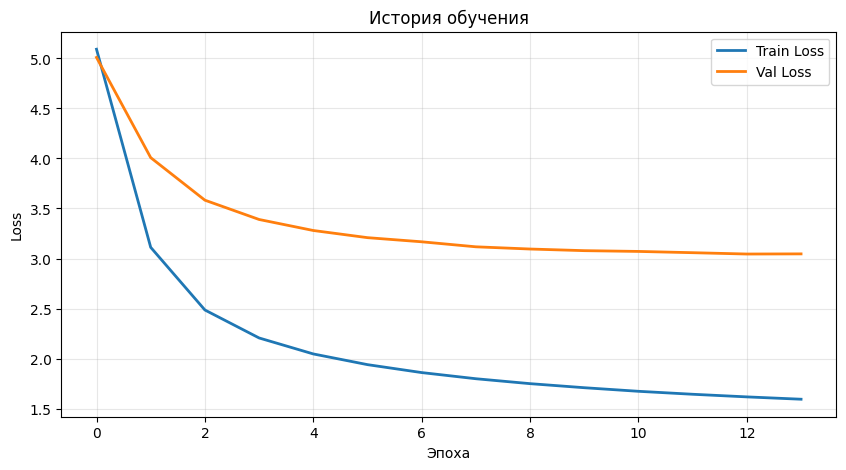

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss', linewidth=2)
plt.plot(history['val_loss'], label='Val Loss', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('История обучения')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Простые примеры перевода

In [20]:
print("ПЕРЕВОД ТЕКСТА:")

def translate(model, src_text, sp_en, sp_ru, device, max_len=60):
    model.eval()
    src_indices = [1] + sp_en.encode(src_text, out_type=int)[:max_len-2] + [2]
    src_tensor = torch.tensor(src_indices).unsqueeze(0).to(device)
    trg_indices = [1]
    with torch.no_grad():
        for _ in range(max_len):
            trg_tensor = torch.tensor(trg_indices).unsqueeze(0).to(device)
            output = model(src_tensor, trg_tensor)
            pred_token = output.argmax(-1)[:, -1].item()
            trg_indices.append(pred_token)
            if pred_token == 2:
                break
    translated = sp_ru.decode([t for t in trg_indices if t != 0 and t != 1 and t != 2])
    return translated


# Тестовые примеры
test_examples = [
    "I am here.",
    "He is good.",
    "I see a cat.",
    "The dog is big.",
    "This is my house.",
    "We go home.",
    "She eats an apple.",
    "I have a car."
]

for i, text in enumerate(test_examples, 1):
    translation = translate(model, text, sp_en, sp_ru, device)
    print(f"{i}. EN: {text}\n   RU: {translation}\n")


ПЕРЕВОД ТЕКСТА:
1. EN: I am here.
   RU: Я здесь.

2. EN: He is good.
   RU: Он добр.

3. EN: I see a cat.
   RU: Я вижу ко ката.

4. EN: The dog is big.
   RU: соба доса очень большой.

5. EN: This is my house.
   RU: Это мой дом мой.

6. EN: We go home.
   RU: Мы отправляем домой.

7. EN: She eats an apple.
   RU: Она ест ябло ябло ябло яблоку.

8. EN: I have a car.
   RU: у меня есть машину.



## Визуализации маски внимания

EN: This is my house
Model RU: Это мой дом


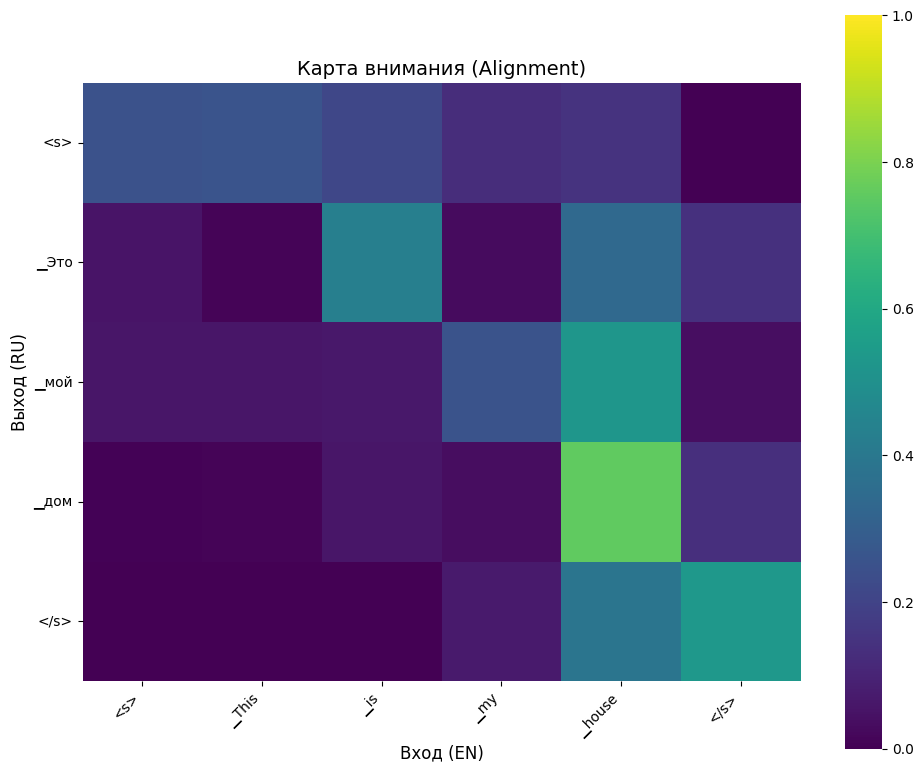

In [21]:
    import matplotlib.pyplot as plt
    import seaborn as sns
    import torch
    import math
    
    def get_attention_weights(model, src_text, trg_text, sp_en, sp_ru, device, max_len=60):
        model.eval()
        
        src_indices = [1] + sp_en.encode(src_text, out_type=int)[:max_len-2] + [2]
        trg_indices = [1] + sp_ru.encode(trg_text, out_type=int)[:max_len-2] + [2]
        
        src_tensor = torch.tensor(src_indices).unsqueeze(1).to(device) # (seq_len, 1)
        trg_tensor = torch.tensor(trg_indices).unsqueeze(1).to(device) # (seq_len, 1)
        
        src_tokens = [t.replace(' ', '').replace(' ', '') for t in sp_en.id_to_piece(src_indices)]
        trg_tokens = [t.replace(' ', '').replace(' ', '') for t in sp_ru.id_to_piece(trg_indices)]
    
        with torch.no_grad():
            src_emb = model.pos_encoder(model.src_embedding(src_tensor) * math.sqrt(model.d_model))
            trg_emb = model.pos_encoder(model.trg_embedding(trg_tensor) * math.sqrt(model.d_model))
            
            encoder_output = model.transformer.encoder(src_emb)
            decoder_layer = model.transformer.decoder.layers[0]
            tgt_seq_len = trg_tensor.shape[0]
            tgt_mask = model.transformer.generate_square_subsequent_mask(tgt_seq_len).to(device)
            
            tgt2, _ = decoder_layer.self_attn(trg_emb, trg_emb, trg_emb, attn_mask=tgt_mask)
            
            tgt2 = trg_emb + tgt2
            
            _, cross_attn_weights = decoder_layer.multihead_attn(
                tgt2, encoder_output, encoder_output, 
                average_attn_weights=True
            )
            
        attention = cross_attn_weights[0].cpu().numpy()
        
        return attention, src_tokens, trg_tokens
    
    def visualize_attention(attention, src_tokens, trg_tokens, save_path='attention.png'):
        plt.figure(figsize=(10, 8))
        
        sns.heatmap(
            attention,
            xticklabels=src_tokens,
            yticklabels=trg_tokens,
            cmap='viridis',
            annot=False,
            cbar=True,
            square=True,
            vmin=0.0, 
            vmax=1.0
        )
        
        plt.xlabel('Вход (EN)', fontsize=12)
        plt.ylabel('Выход (RU)', fontsize=12)
        plt.title('Карта внимания (Alignment)', fontsize=14)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.savefig(save_path, dpi=150)
        plt.show()
    
    example_src = "This is my house"
    example_trg = "Это мой дом"
    
    pred_ru = translate(model, example_src, sp_en, sp_ru, device)
    print(f"EN: {example_src}")
    print(f"Model RU: {pred_ru}")
    
    if len(pred_ru) > 0:
        att, src_tok, trg_tok = get_attention_weights(
            model, example_src, pred_ru, sp_en, sp_ru, device
        )
        visualize_attention(att, src_tok, trg_tok)

# Выводы:

Если смотреть на примеры перевода, видно что:

1. Модель в принципе понимает базовые соответствия слов («This is my house» → «Это мой дом»), часто хорошо переводит простые короткие фразы. Например по картинке видно, что есть сильные веса между содержательными токенами(дом - house).
2. Не совсем понятные вещи выдает в длинных предложениях, но смысл понять можно.
3. Иногда повторы и артефакты subword при генерации длинных последовательностей
4. Появляются английские слова, видимо они тоже были русской части.

При генерации каждый таргет-токен смотрит на подходящие позиционные представления энкодера, сильные пики внимания, то прямая передача лексики, если же размытое внимание, то неопределённость

## Для улучшениия:

1. Увеличить датасет
2. Использовать beam search
   